# Rare-Disease Synthetic Data Augmentation — Day 4: The Main Experiment

**The research question:** does adding GAN-generated Dermatofibroma (DF) images help the classifier catch the rare disease —
compared with the baseline and the simpler methods from Day 2?

Every method is trained with **exactly the same recipe** (Day 1) and adds **the same 500 extra DF training samples** —
only *where those 500 come from* changes:

| Method | The 500 extra DF samples |
|---|---|
| Baseline | none |
| Oversample only | copies of the 71 real DF images |
| Classic aug | the same copies, randomly flipped / rotated / cropped / brightness-changed |
| SMOTE | blends of two similar real DF images (Day 2) |
| **GAN** | **new images from the GAN (Day 3)** |

**Plan**

* **Part A** — train the GAN method with seed 42 → directly comparable with the Day 1–2 results (~5 min)
* **Part B** — repeat **every** method with two more random seeds (43, 44) → 3 runs per method, so we can tell a real
  improvement from luck (~45–60 min)
* **Part C** — results across seeds, where each method succeeds or fails, and a check for "shortcuts"

**Before running:** upload `rare-disease-aug-day4.zip` to **My Drive**. Then `Runtime → Change runtime type → T4 GPU` and
`Runtime → Run all`. Total ≈ 60–75 min — you can leave it running. **If Colab disconnects, just `Run all` again:**
finished runs are skipped automatically and it continues with the rest.

## 0 · Setup

In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv || echo "⚠️ No GPU — Runtime > Change runtime type > T4 GPU"

name, memory.total [MiB]
NVIDIA GeForce RTX 4060 Laptop GPU, 8188 MiB


In [2]:
import os, sys, zipfile
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

# Colab: the project on Google Drive. Laptop: the folder this notebook sits in (…/rare-disease-aug/notebooks).
_local = Path.cwd().parent if (Path.cwd().parent / 'src').exists() else Path.cwd()
PROJECT_DIR = Path(os.environ.get('RDA_PROJECT_DIR',
                   '/content/drive/MyDrive/rare-disease-aug' if Path('/content').exists() else str(_local)))
RAW_DIR     = Path(os.environ.get('RDA_RAW_DIR', '/content/ham10000_raw'))   # not needed today

ZIP_NAME = 'rare-disease-aug-day4.zip'
for folder in [PROJECT_DIR.parent, PROJECT_DIR.parent / 'Colab Notebooks']:
    if (folder / ZIP_NAME).exists():
        zipfile.ZipFile(folder / ZIP_NAME).extractall(PROJECT_DIR.parent)
        print('Code updated from', folder / ZIP_NAME)
        break
assert (PROJECT_DIR / 'src' / 'experiments.py').exists(), f'Upload {ZIP_NAME} to My Drive first'

os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR))
print('Project dir:', PROJECT_DIR)

Project dir: C:\rare-disease-aug


In [3]:
import json
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from IPython.display import display

from src.config import Paths, CLASS_CODES, CLASS_NAMES
from src.data.explore import build_metadata
from src.data.split import make_split
from src.data.preprocess import build_image_cache
from src.data.dataset import attach_cache_index
from src.experiments import CONFIGS, CONFIG_ORDER, run_config, completed_runs, synthetic_path
from src.compare import comparison_table, plot_rare_metrics
from src.analysis import (load_log, seed_summary, paired_vs_baseline, plot_seed_comparison, load_predictions,
                          per_image_hits, false_positive_sources, shortcut_table)
from src.gan.viz import image_rows

pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 30)
paths = Paths(PROJECT_DIR, RAW_DIR)
FIG = paths.figures_dir
print(f'torch {torch.__version__} | CUDA: {torch.cuda.is_available()}')

torch 2.14.0+cu126 | CUDA: True


## 1 · Load the data and check what's already done

In [4]:
info = json.loads(paths.dataset_info_json.read_text())
RARE = info['rare_class']
RARE_IDX = CLASS_CODES.index(RARE)

meta = build_metadata(paths)
split = make_split(meta, paths, seed=42)             # the fixed Day 1 split — same test set as every earlier run
images = build_image_cache(meta, paths, size=224)
split = attach_cache_index(split, meta)
train_df = split[split.split == 'train'].reset_index(drop=True)

N_EXTRA = 500
EPOCHS = 15          # same as Days 1–2 — do not change, or the comparison is no longer fair
PRETRAINED = True

done = completed_runs(paths)
status = pd.DataFrame([[('✅' if (c, s) in done else '—') for s in (42, 43, 44)] for c in CONFIG_ORDER],
                      index=[CONFIGS[c]['label'] for c in CONFIG_ORDER], columns=['seed 42', 'seed 43', 'seed 44'])
print(f'Rare class: {RARE} ({CLASS_NAMES[RARE]}) | real {RARE} training images: {(train_df.label == RARE).sum()}')
display(status)

[reuse] raw data not on disk; loading saved C:\rare-disease-aug\data\processed\metadata.csv
[reuse] existing split C:\rare-disease-aug\data\splits\split_seed42.csv
[reuse] image cache C:\rare-disease-aug\data\processed\images_224px_uint8.npy  shape=(10015, 224, 224, 3)
Loading images_224px_uint8.npy into RAM ...
Rare class: DF (Dermatofibroma) | real DF training images: 71


,seed 42,seed 43,seed 44
Baseline (no aug),✅,—,—
Oversample only,✅,—,—
Classic aug,✅,—,—
SMOTE interp.,✅,—,—
GAN aug,—,—,—


## 2 · Shortcut check (before training)

The classifier only ever sees synthetic images **in the DF class**. If they differ from real DF images in some simple
way — colour, blur — the classifier might learn *that* instead of the lesion. The test set is 100 % real images, so such a
shortcut can't fake a better score; it can only make the synthetic images less useful. Still, it helps explain the results.

Compare the rows: the closer **GAN** and **SMOTE** are to **real DF**, the smaller the risk.

In [5]:
rng = np.random.default_rng(0)
real_df = np.stack([images[i] for i in train_df.loc[train_df.label == RARE, 'cache_idx']])
other_idx = rng.choice(train_df.loc[train_df.label != RARE, 'cache_idx'].to_numpy(), 500, replace=False)
sets = {f'Real {RARE} (training)': real_df,
        'Real other classes (500 random)': np.stack([images[i] for i in other_idx])}
for kind, name in [('gan', f'GAN {RARE} (500)'), ('smote', f'SMOTE {RARE} (500)')]:
    f = synthetic_path(paths, kind, RARE, N_EXTRA)
    if f.exists():
        sets[name] = np.load(f)
shortcuts = shortcut_table(sets)
shortcuts.to_csv(paths.results_dir / 'shortcut_check.csv')
display(shortcuts)

,n,mean R,mean G,mean B,redness (R−G),sharpness (Laplacian var)
Real DF (training),71,201.9,150.4,157.9,51.5,93.2
Real other classes (500 random),500,192.4,139.5,146.8,52.9,70.7
GAN DF (500),500,202.8,147.0,152.7,55.8,9.9
SMOTE DF (500),500,203.9,150.4,156.7,53.6,55.5


*Redness* = average red minus average green (higher = redder). *Sharpness* = how much fine detail the image has
(the GAN works at 128 px and is enlarged to 224 px, so a lower value is expected).

## 3 · Part A — the GAN method, seed 42

Directly comparable with the Day 1 and Day 2 runs (same seed).


=== GAN aug | seed 42 | extra DF samples: 500 ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 17.5MB/s]


Device: cuda | AMP: True | train=7481 (rare DF: 571) | val=1532 | test=1502
ep 01/15 | loss 0.6416 / val 0.5283 | val acc 0.823 macroF1 0.620 | DF P 0.67 R 0.17 F1 0.27 (pred 6) | 33s  *best*
ep 02/15 | loss 0.2458 / val 0.5814 | val acc 0.817 macroF1 0.617 | DF P 0.50 R 0.25 F1 0.33 (pred 12) | 12s
ep 03/15 | loss 0.0739 / val 0.6129 | val acc 0.808 macroF1 0.590 | DF P 0.33 R 0.12 F1 0.18 (pred 9) | 12s
ep 04/15 | loss 0.0213 / val 0.6007 | val acc 0.828 macroF1 0.621 | DF P 0.57 R 0.17 F1 0.26 (pred 7) | 13s  *best*
ep 05/15 | loss 0.0074 / val 0.6097 | val acc 0.832 macroF1 0.636 | DF P 0.60 R 0.25 F1 0.35 (pred 10) | 13s  *best*
ep 06/15 | loss 0.0045 / val 0.6131 | val acc 0.820 macroF1 0.622 | DF P 0.62 R 0.21 F1 0.31 (pred 8) | 13s
ep 07/15 | loss 0.0041 / val 0.6552 | val acc 0.828 macroF1 0.634 | DF P 0.71 R 0.21 F1 0.32 (pred 7) | 13s
ep 08/15 | loss 0.0036 / val 0.6296 | val acc 0.834 macroF1 0.634 | DF P 0.57 R 0.17 F1 0.26 (pred 7) | 14s
ep 09/15 | loss 0.0025 / val 0.640

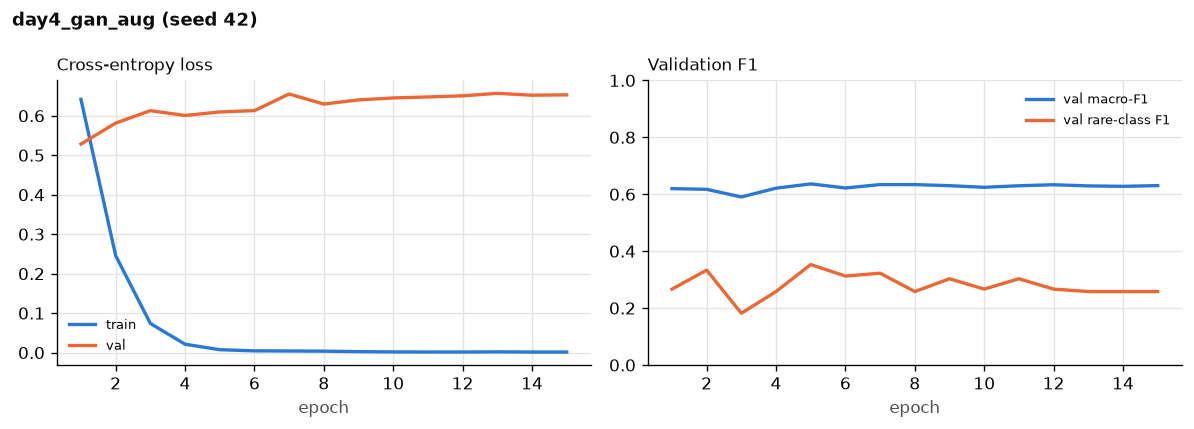

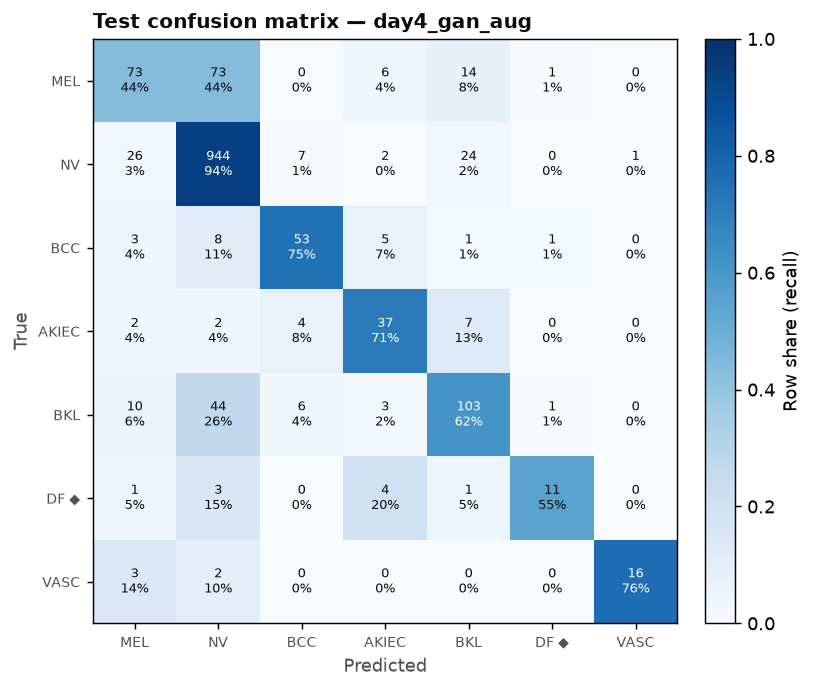


Saved run artefacts to C:\rare-disease-aug\results\runs\day4_gan_aug_seed42
Appended results row to C:\rare-disease-aug\results\results_log.csv
--> TEST DF: recall 0.55  precision 0.79  F1 0.65 | macro-F1 0.713


In [6]:
_ = run_config('gan_aug', 42, paths, images, split, RARE, n_extra=N_EXTRA, epochs=EPOCHS, pretrained=PRETRAINED,
               show_plots=True)

,n_extra,n_train_rare,test_accuracy,test_macro_f1,rare_precision,rare_recall,recall_95ci,rare_f1,rare_auroc,best_epoch,Δrare_recall,Δrare_f1
Baseline (no aug),0,71,0.820,0.684,0.562,0.45,0.26–0.66,0.500,0.951,14,0.00,0.000
Oversample only,500,571,0.819,0.689,0.727,0.40,0.22–0.61,0.516,0.972,4,-0.05,0.016
Classic aug,500,571,0.826,0.698,0.538,0.70,0.48–0.85,0.609,0.960,15,0.25,0.109
SMOTE interp.,500,571,0.824,0.700,0.750,0.45,0.26–0.66,0.562,0.968,9,0.00,0.062
GAN aug,500,571,0.824,0.713,0.786,0.55,0.34–0.74,0.647,0.978,5,0.10,0.147


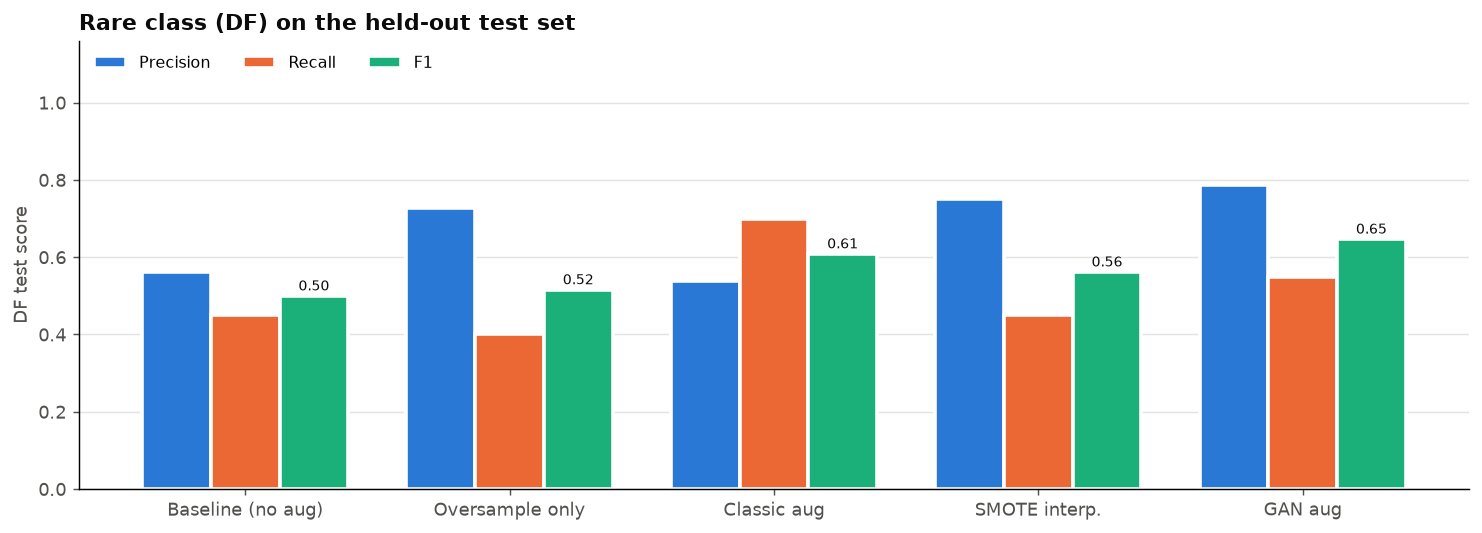

In [7]:
table42 = comparison_table(paths.results_log, seed=42)
display(table42)
plot_rare_metrics(table42, RARE, FIG / 'day4_seed42_comparison.png')

## 4 · Part B — repeat every method with seeds 43 and 44

Ten more training runs (~4–6 min each). Only the progress lines are printed; every run's curves, confusion matrix and
predictions are still saved in `results/runs/`. Already-finished runs are skipped, so this cell is safe to re-run.

In [8]:
SEEDS = [43, 44]
for seed in SEEDS:
    for cfg in CONFIG_ORDER:
        run_config(cfg, seed, paths, images, split, RARE, n_extra=N_EXTRA, epochs=EPOCHS, pretrained=PRETRAINED)
print('\nAll runs finished.')


=== Baseline (no aug) | seed 43 | extra DF samples: 0 ===
Device: cuda | AMP: True | train=6981 (rare DF: 71) | val=1532 | test=1502
ep 01/15 | loss 0.7369 / val 0.6435 | val acc 0.783 macroF1 0.489 | DF P 0.00 R 0.00 F1 0.00 (pred 4) | 30s  *best*
ep 02/15 | loss 0.2630 / val 0.5772 | val acc 0.803 macroF1 0.548 | DF P 0.30 R 0.12 F1 0.18 (pred 10) | 12s  *best*
ep 03/15 | loss 0.0972 / val 0.6192 | val acc 0.807 macroF1 0.619 | DF P 0.45 R 0.21 F1 0.29 (pred 11) | 12s  *best*
ep 04/15 | loss 0.0292 / val 0.6402 | val acc 0.824 macroF1 0.614 | DF P 0.33 R 0.17 F1 0.22 (pred 12) | 13s
ep 05/15 | loss 0.0118 / val 0.6611 | val acc 0.810 macroF1 0.594 | DF P 0.44 R 0.17 F1 0.24 (pred 9) | 12s
ep 06/15 | loss 0.0068 / val 0.6619 | val acc 0.817 macroF1 0.622 | DF P 0.56 R 0.21 F1 0.30 (pred 9) | 12s  *best*
ep 07/15 | loss 0.0051 / val 0.6697 | val acc 0.826 macroF1 0.609 | DF P 0.38 R 0.12 F1 0.19 (pred 8) | 12s
ep 08/15 | loss 0.0034 / val 0.6670 | val acc 0.819 macroF1 0.597 | DF P 0.

## 5 · Part C — results across seeds

**Mean ± standard deviation over the seeds.** Remember: the test set has only 20 DF images, so each image is 5 points
of recall. Differences smaller than the spread between seeds are not reliable.

,seeds,Accuracy,Macro-F1,DF precision,DF recall,DF F1,DF AUROC,DF caught (all seeds)
method,,,,,,,,
Baseline (no aug),3,0.819 ± 0.002,0.678 ± 0.014,0.685 ± 0.111,0.433 ± 0.076,0.524 ± 0.057,0.968 ± 0.017,26 / 60
Oversample only,3,0.818 ± 0.002,0.677 ± 0.022,0.732 ± 0.099,0.417 ± 0.076,0.531 ± 0.088,0.957 ± 0.038,25 / 60
Classic aug,3,0.825 ± 0.005,0.695 ± 0.017,0.618 ± 0.127,0.633 ± 0.076,0.620 ± 0.077,0.938 ± 0.033,38 / 60
SMOTE interp.,3,0.818 ± 0.006,0.696 ± 0.008,0.767 ± 0.018,0.550 ± 0.100,0.637 ± 0.071,0.971 ± 0.004,33 / 60
GAN aug,3,0.821 ± 0.003,0.701 ± 0.010,0.833 ± 0.060,0.550 ± 0.100,0.656 ± 0.062,0.952 ± 0.037,33 / 60


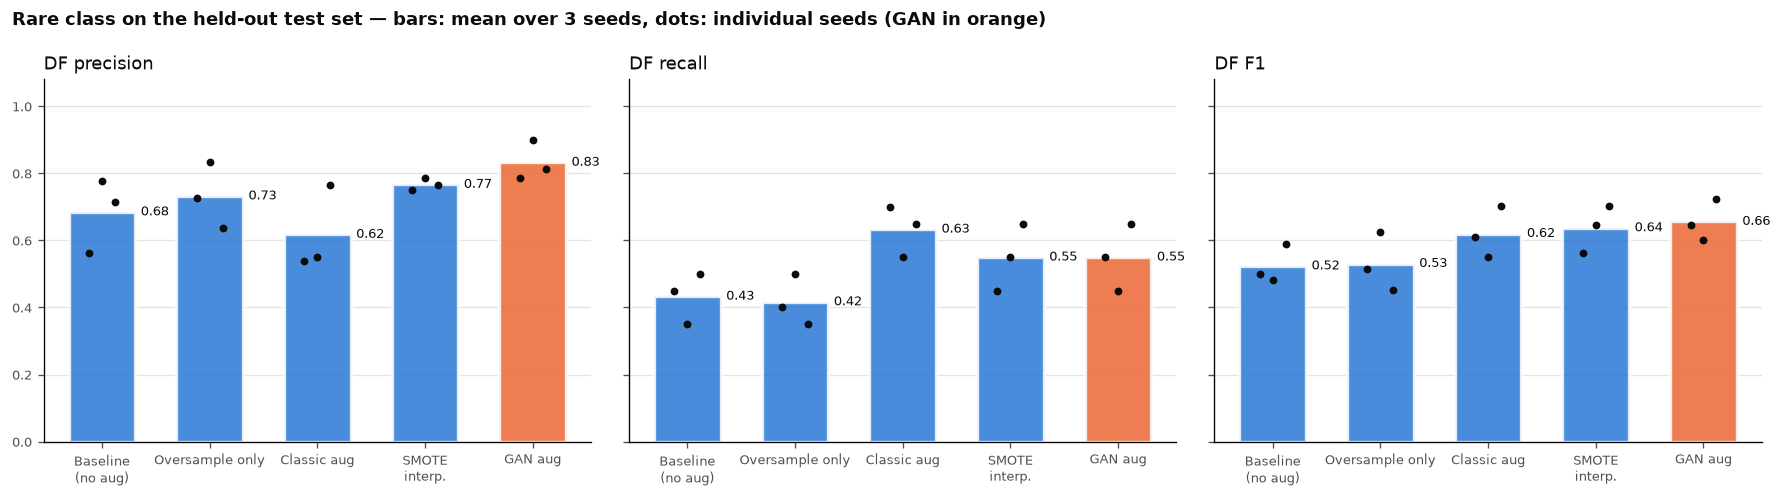

In [9]:
log = load_log(paths)
summary = seed_summary(log, RARE)
summary.to_csv(paths.results_dir / 'final_comparison.csv')
display(summary)
plot_seed_comparison(log, RARE, FIG / 'day4_final_comparison.png')

### Same seed, head to head

Each method compared with the baseline **trained with the same seed** (same starting point and batch order), so only the
extra images differ. *better / same / worse* counts the seeds.

In [10]:
paired_f1 = paired_vs_baseline(log, 'rare_f1')
paired_recall = paired_vs_baseline(log, 'rare_recall')
paired_f1.to_csv(paths.results_dir / 'final_paired_f1.csv')
print(f'Change in {RARE} F1 vs baseline:')
display(paired_f1)
print(f'\nChange in {RARE} recall vs baseline:')
display(paired_recall)

Change in DF F1 vs baseline:


,seed 42,seed 43,seed 44,mean change,better,same,worse
method,,,,,,,
Oversample only,0.016,0.142,-0.137,0.007,2,0,1
Classic aug,0.109,0.067,0.115,0.097,3,0,0
SMOTE interp.,0.062,0.164,0.115,0.114,3,0,0
GAN aug,0.147,0.117,0.134,0.133,3,0,0



Change in DF recall vs baseline:


,seed 42,seed 43,seed 44,mean change,better,same,worse
method,,,,,,,
Oversample only,-0.05,0.15,-0.15,-0.017,1,0,2
Classic aug,0.25,0.20,0.15,0.200,3,0,0
SMOTE interp.,0.00,0.20,0.15,0.117,2,1,0
GAN aug,0.10,0.10,0.15,0.117,3,0,0


## 6 · Where each method succeeds and fails

**Per test image:** each row is one of the 20 real DF test images; each value is the share of seeds in which that method
recognised it (1.0 = every time, 0 = never). Darker = caught more often.

In [11]:
preds = load_predictions(paths, log)
hits = per_image_hits(preds, RARE)
hits.to_csv(paths.results_dir / 'final_per_image_hits.csv')
method_cols = [c for c in hits.columns if c != 'lesion_id']
display(hits.style.background_gradient(cmap='Blues', vmin=0, vmax=1, subset=method_cols).format(precision=2, subset=method_cols))

,lesion_id,Baseline (no aug),Oversample only,Classic aug,SMOTE interp.,GAN aug
image_id,,,,,,
ISIC_0024994,HAM_0002960,1.00,1.00,1.00,1.00,1.00
ISIC_0025223,HAM_0000827,1.00,1.00,1.00,0.67,1.00
ISIC_0026313,HAM_0007418,0.33,0.00,0.67,0.00,0.33
ISIC_0027488,HAM_0003597,1.00,1.00,1.00,0.67,1.00
ISIC_0029760,HAM_0004330,0.33,0.00,0.67,0.67,0.00
ISIC_0029962,HAM_0007410,0.00,0.00,1.00,0.00,0.33
ISIC_0029973,HAM_0002045,0.67,1.00,0.33,1.00,1.00
ISIC_0030555,HAM_0004330,0.00,0.00,0.33,0.67,0.00
ISIC_0030579,HAM_0002546,0.67,0.33,1.00,0.67,1.00


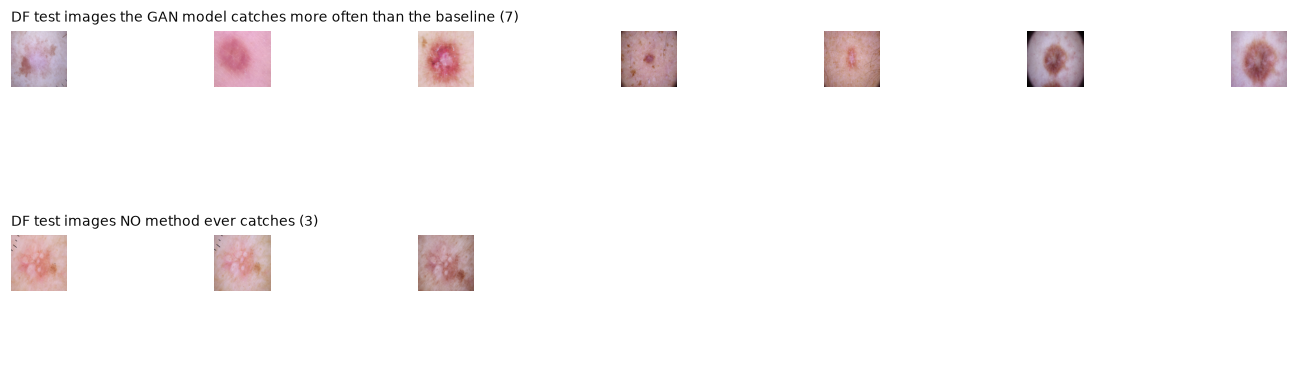

GAN catches more often than baseline: 7 images | missed by every method, every seed: 3 images


In [12]:
id_to_cache = dict(zip(split.image_id, split.cache_idx))
base_col, gan_col = CONFIGS['baseline_no_aug']['label'], CONFIGS['gan_aug']['label']
gain = hits.index[hits[gan_col] > hits[base_col]]
never = hits.index[(hits[method_cols] == 0).all(axis=1)]
rows, titles = [], []
if len(gain):
    rows.append(np.stack([images[id_to_cache[i]] for i in gain[:8]]))
    titles.append(f'{RARE} test images the GAN model catches more often than the baseline ({len(gain)})')
if len(never):
    rows.append(np.stack([images[id_to_cache[i]] for i in never[:8]]))
    titles.append(f'{RARE} test images NO method ever catches ({len(never)})')
if rows:
    image_rows(rows, titles, out=FIG / 'day4_success_failure_examples.png', size=1.7)
print(f'GAN catches more often than baseline: {len(gain)} images | missed by every method, every seed: {len(never)} images')

**False alarms:** which other diseases get wrongly labelled as DF (average per run). If the GAN images taught the model a
colour shortcut, we'd expect extra false alarms from similar-coloured classes.

In [13]:
fp = false_positive_sources(preds, RARE)
fp.to_csv(paths.results_dir / 'final_false_alarms.csv')
display(fp)

,Baseline (no aug),Oversample only,Classic aug,SMOTE interp.,GAN aug
label,,,,,
MEL,1.3,0.7,1.7,1.3,1.0
NV,0.3,0.0,2.3,0.3,0.0
BCC,0.7,0.7,0.7,0.7,0.3
AKIEC,0.7,0.7,1.7,0.0,0.3
BKL,1.3,1.0,2.0,1.0,0.7
VASC,0.0,0.0,0.0,0.0,0.0
TOTAL false alarms,4.3,3.1,8.4,3.3,2.3


## 7 · Summary

In [14]:
def ms(cfg, col):
    v = log.loc[log.config == cfg, col]
    return round(float(v.mean()), 3), round(float(v.std(ddof=1)) if len(v) > 1 else 0.0, 3), int(len(v))

final = {'rare_class': RARE, 'n_extra': N_EXTRA, 'test_rare_images': int(log.rare_support.iloc[0]),
         'methods': {CONFIGS[c]['label']: {m: ms(c, col) for m, col in
                     [('rare_f1', 'rare_f1'), ('rare_recall', 'rare_recall'), ('rare_precision', 'rare_precision'),
                      ('macro_f1', 'test_macro_f1'), ('accuracy', 'test_accuracy')]}
                     for c in CONFIG_ORDER if (log.config == c).any()}}
(paths.results_dir / 'final_summary.json').write_text(json.dumps(final, indent=2))

best = max(final['methods'].items(), key=lambda kv: kv[1]['rare_f1'][0])
print(f"Highest mean {RARE} F1: {best[0]} ({best[1]['rare_f1'][0]:.3f} ± {best[1]['rare_f1'][1]:.3f})")
for name, m in final['methods'].items():
    print(f"  {name:18s} {RARE} F1 {m['rare_f1'][0]:.3f} ± {m['rare_f1'][1]:.3f} | recall {m['rare_recall'][0]:.3f} "
          f"| precision {m['rare_precision'][0]:.3f} | macro-F1 {m['macro_f1'][0]:.3f}  (n={m['rare_f1'][2]} seeds)")

Highest mean DF F1: GAN aug (0.656 ± 0.062)
  Baseline (no aug)  DF F1 0.524 ± 0.057 | recall 0.433 | precision 0.685 | macro-F1 0.678  (n=3 seeds)
  Oversample only    DF F1 0.531 ± 0.088 | recall 0.417 | precision 0.732 | macro-F1 0.677  (n=3 seeds)
  Classic aug        DF F1 0.620 ± 0.077 | recall 0.633 | precision 0.618 | macro-F1 0.695  (n=3 seeds)
  SMOTE interp.      DF F1 0.637 ± 0.071 | recall 0.550 | precision 0.767 | macro-F1 0.696  (n=3 seeds)
  GAN aug            DF F1 0.656 ± 0.062 | recall 0.550 | precision 0.833 | macro-F1 0.701  (n=3 seeds)


## ✅ Day 4 checklist

`File → Download → Download .ipynb` and send it back. I'll go through:

* the seed-42 table (Part A) and the **across-seeds table and chart** (Part C) — the project's main result
* the head-to-head changes vs the baseline — is the GAN's effect consistent across seeds?
* which DF images the GAN helps with, which nobody catches, and whether false alarms rose
* the shortcut check

Then Day 5: the web app.